In [1]:
# pip install pyarrow==22.0.0

In [3]:
from degradation_toolbox.Urc.Urc import Urc
from degradation_toolbox.Urc.Urc1 import Urc1
import pandas as pd
import numpy as np
import pickle
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from utils.investigate import Urc1OutlierInvestigator

In [5]:
data = pd.read_parquet(r"G1M1_new.parquet")

#data["currentDensity"] = data.row_current_A / 5000

#col_temperature = [col for col in data.columns if "temperature" in col]
#data["temperature"] = data[col_temperature].mean(axis=1)

#data = data.rename(columns={"cell_voltage_mean_V": "voltage"})'

print(data.head())
print(data.tail())


                     currentDensity  temperature   voltage
timestamp                                                 
2021-02-12 00:00:00       -0.000468    18.932346  0.016223
2021-02-12 00:01:00       -0.000504    18.913280  0.016252
2021-02-12 00:02:00       -0.000429    18.907166  0.016276
2021-02-12 00:03:00       -0.000392    18.900766  0.016371
2021-02-12 00:04:00       -0.000345    18.894279  0.016230
                     currentDensity  temperature   voltage
timestamp                                                 
2025-12-09 09:55:00        0.000276    19.819897  0.006083
2025-12-09 09:56:00        0.000206    19.819767  0.006198
2025-12-09 09:57:00        0.000073    19.805811  0.006228
2025-12-09 09:58:00        0.000159    19.798054  0.006298
2025-12-09 09:59:00        0.000163    19.789055  0.006322


In [ ]:
results = Urc(data, Iref=[0.6, 1.5], min_num_data_required_for_fit=300, configDict={'plotSummary': True, 'jEvalList': [5]})

In [ ]:
# results.plot_interactive_Urc1(0.6)
# results.plot_interactive_Urc1(1.5)

In [ ]:
# results.Urc1_results_incl_unreliable

In [ ]:
urc1_preprocess = Urc1(data=data,min_num_data_required_for_fit=300)

Data preprocessing ...
Before preprocess: 2529217 data points.
After preprocess: 1069062 data points.
 (Filter criteria: i>0.1A/cm2, 1.4V<U<2.3V, 50degC<T<65degC, h_since_last_start>0.5h.)

Voltage model fitting ...
476 out of 1761 fitting intervals do not have sufficient data.
0 out of 1761 fitting intervals failed the curve_fit function.
1095 out of 1286 fitting results are reliable.


In [7]:
investigator = Urc1OutlierInvestigator(urc1_instance=urc1_preprocess, raw_data=data)

Urc1 Investigator Initialized.
  Anchor Time:     2021-02-12 11:20:00
  Interval Length: 2 days


Starting investigation for: 2022-06-12...

Interval Locked: 2022-06-12 11:20:00 to 2022-06-14 11:20:00
Data Extraction Report:
  1. Raw Data Points:        2881
  2. Urc1 Preprocessed Pts:  511 (Used for fitting)
  3. Actual Data Coverage:   2022-06-12 11:20:00  ->  2022-06-14 11:20:00
      (Duration Covered:      48.0 hours)

==================== 1. Basic Statistics (Urc1 Preprocessed) ====================


,currentDensity,voltage,temperature,log_h
count,511.000000,511.000000,511.000000,511.000000
mean,0.917395,1.871412,58.303547,1.371697
std,0.364844,0.183465,1.344995,0.691042
min,0.265804,1.617081,54.354633,-0.660357
25%,0.698568,1.737065,57.587839,0.971405
50%,0.999158,1.876605,58.844654,1.561647
75%,1.100399,1.947613,59.258081,1.930312
max,1.500650,2.226279,60.700386,2.199075



==================== 2. Fitting Coefficients (Model Output) ====================
Found 1 results for this time. Showing the first one.


,c1,c1_se,c2,c2_se,c3,c3_se,c4,c4_se,c5,c5_se
Elyzer,0.095774,0.050425,-0.068209,0.048929,-0.00146,0.003021,0.596137,0.010903,0.396534,0.001546



Condition Number (Matrix Health): 9.30e+04

Coefficient Quality Check:
  c1 is Unstable. (Error is large). Ratio: 0.5
  c2 is Unstable. (Error is large). Ratio: 0.7
  c3 is UNRELIABLE! (Error > Value). Ratio: 2.1

==================== 2. Time Series Investigation (4-Way Split) ====================


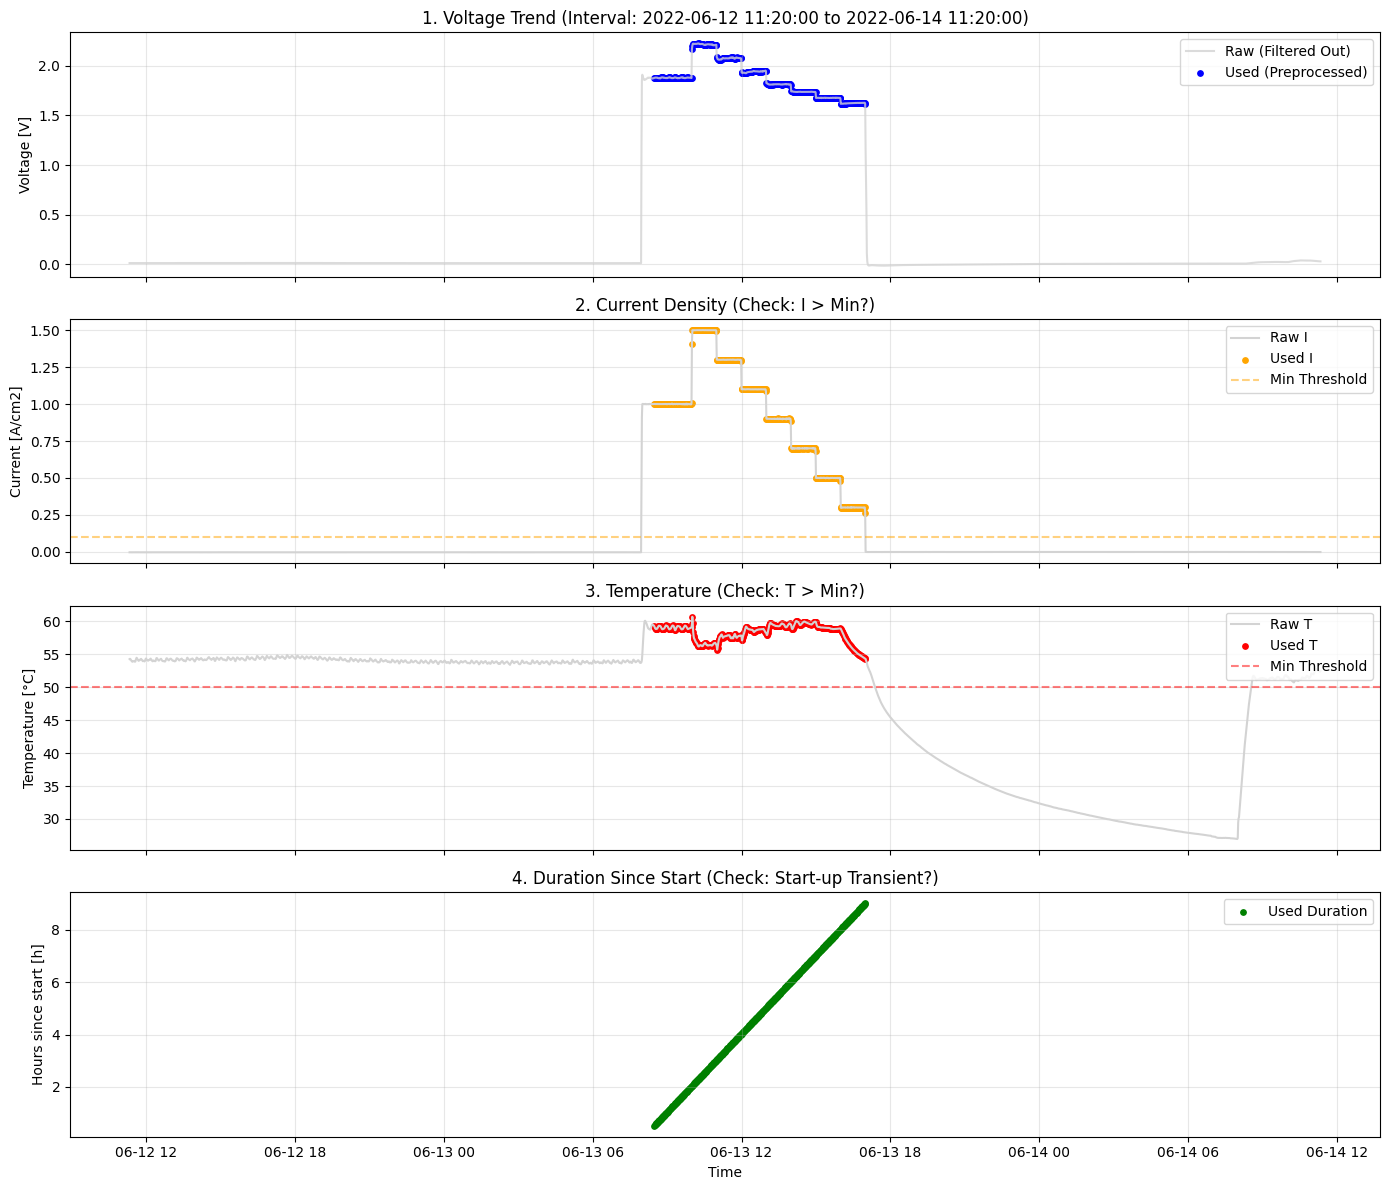


==================== 3-1. Correlation Matrix (Collinearity Check) ====================
                currentDensity  temperature     log_h   voltage
currentDensity        1.000000    -0.061626 -0.603760  0.978331
temperature          -0.061626     1.000000 -0.108757 -0.230116
log_h                -0.603760    -0.108757  1.000000 -0.544985
voltage               0.978331    -0.230116 -0.544985  1.000000

==================== 3-2. Correlation Matrix (Collinearity Check) ====================
                currentDensity  temperature       IxT     log_h        I2
currentDensity        1.000000    -0.061626  0.998630 -0.603760  0.978221
temperature          -0.061626     1.000000 -0.014545 -0.108757 -0.231475
IxT                   0.998630    -0.014545  1.000000 -0.614912  0.967438
log_h                -0.603760    -0.108757 -0.614912  1.000000 -0.543168
I2                    0.978221    -0.231475  0.967438 -0.543168  1.000000

==================== 3-3. Collinearity Check (Features) ===

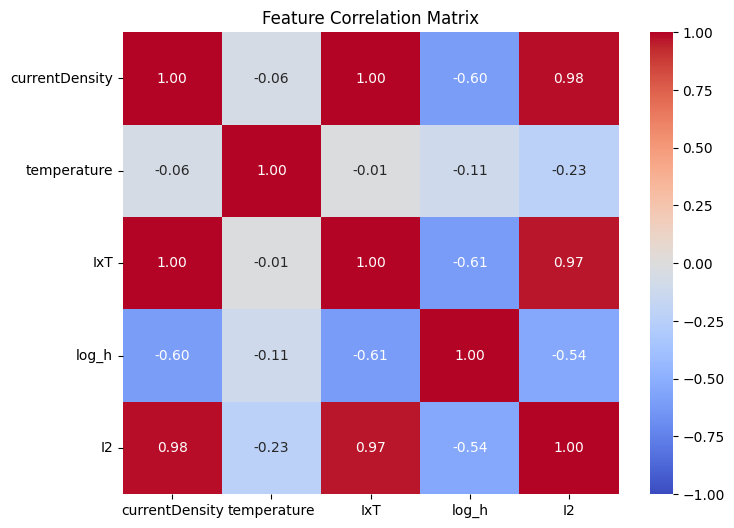


==================== 5. Pairwise Relationships (4D Scan) ====================


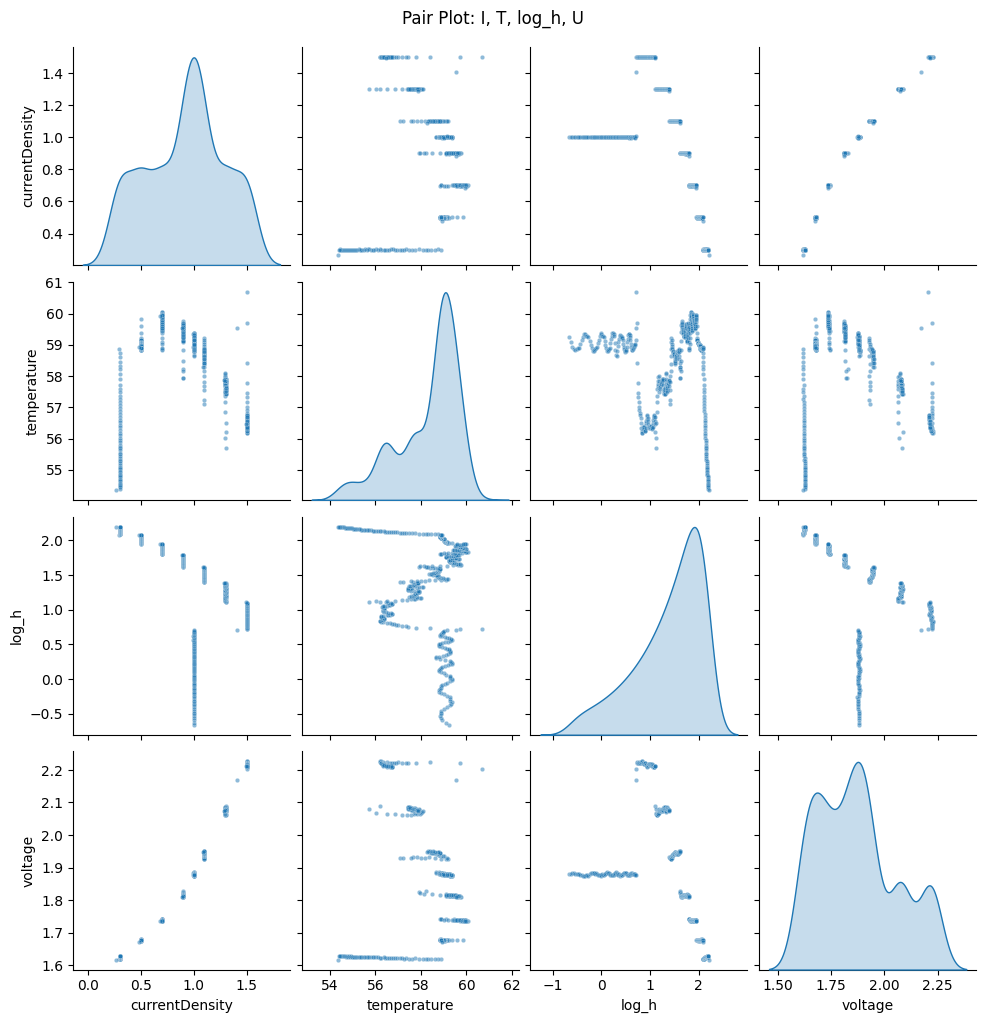


==================== 4. Interactive 3D Spatial Distribution ====================



==================== 6. Joint Distribution (Current vs Temp) ====================


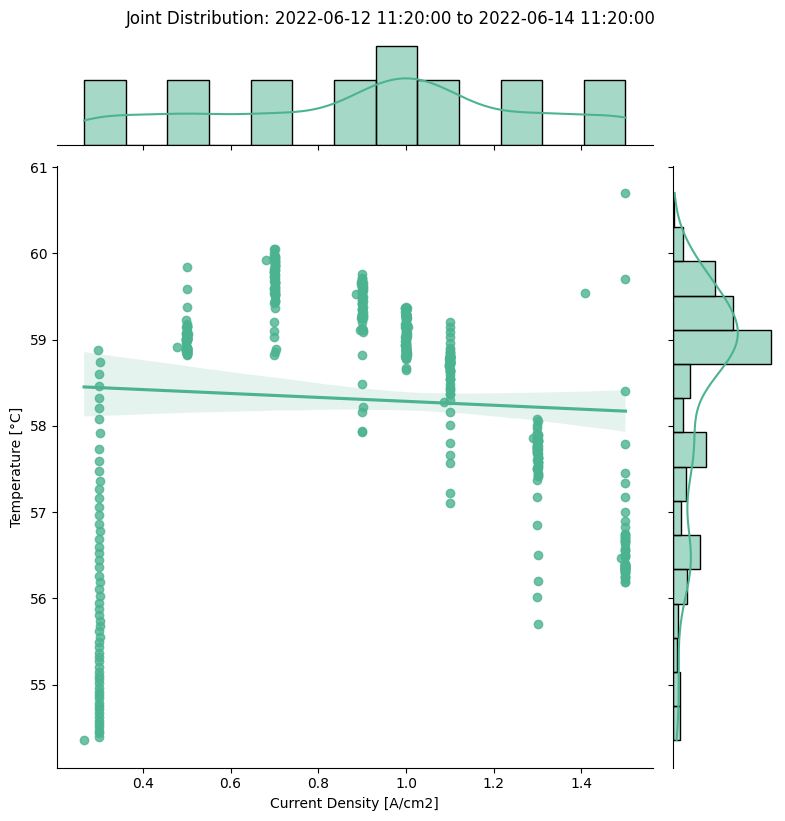


==================== 6. Joint Distribution (logh vs Temp) ====================


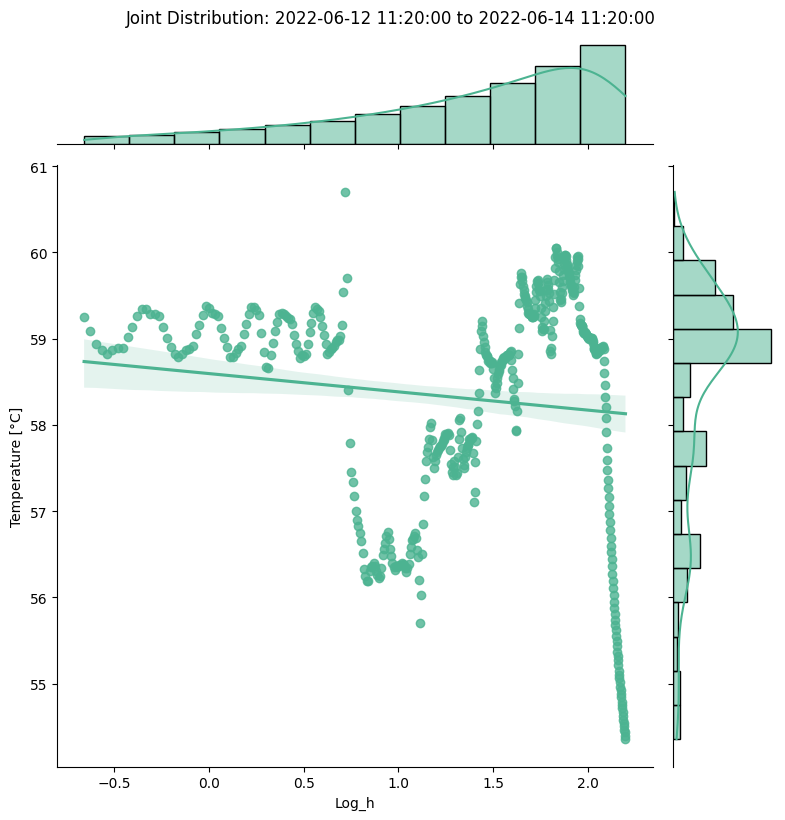

In [8]:
target_date = "2022-06-12"
print(f"Starting investigation for: {target_date}...")
investigator.run_full_diagnosis(target_date)

Starting investigation for: 2025-03-17...

Interval Locked: 2025-03-17 11:20:00 to 2025-03-19 11:20:00
Data Extraction Report:
  1. Raw Data Points:        2881
  2. Urc1 Preprocessed Pts:  446 (Used for fitting)
  3. Actual Data Coverage:   2025-03-17 11:20:00  ->  2025-03-19 11:20:00
      (Duration Covered:      48.0 hours)

==================== 1. Basic Statistics (Urc1 Preprocessed) ====================


,currentDensity,voltage,temperature,log_h
count,446.000000,446.000000,446.000000,446.000000
mean,0.308903,1.657727,56.508293,1.586570
std,0.055440,0.018046,1.627743,0.325674
min,0.297290,1.650458,50.047073,0.788457
25%,0.299621,1.653085,56.528502,1.399744
50%,0.300173,1.654185,56.838024,1.634129
75%,0.301393,1.655614,57.051891,1.829242
max,0.932672,1.859313,60.774712,2.089804



==================== 2. Fitting Coefficients (Model Output) ====================
Found 1 results for this time. Showing the first one.


,c1,c1_se,c2,c2_se,c3,c3_se,c4,c4_se,c5,c5_se
Elyzer,0.78589,0.021168,-0.468381,0.021516,0.009897,0.001975,0.042731,0.019348,0.421917,0.000509



Condition Number (Matrix Health): 2.00e+05

Coefficient Quality Check:

==================== 2. Time Series Investigation (4-Way Split) ====================


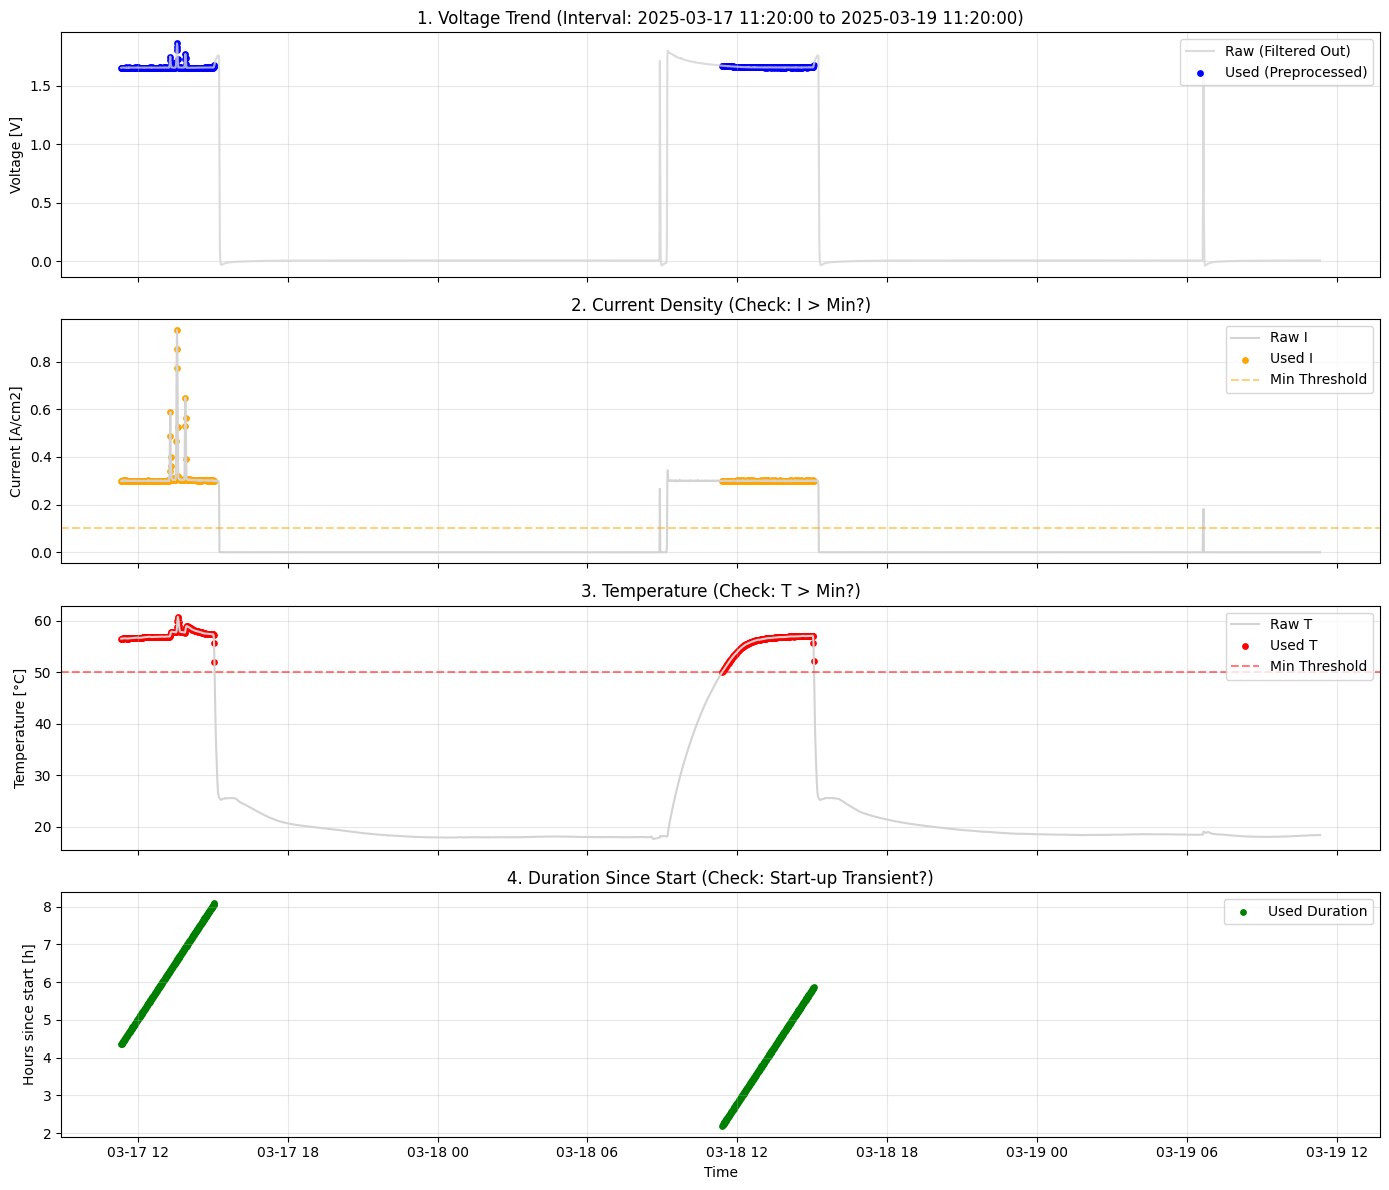


==================== 3-1. Correlation Matrix (Collinearity Check) ====================
                currentDensity  temperature     log_h   voltage
currentDensity        1.000000     0.194835  0.152154  0.975883
temperature           0.194835     1.000000  0.833225 -0.006825
log_h                 0.152154     0.833225  1.000000 -0.001418
voltage               0.975883    -0.006825 -0.001418  1.000000

==================== 3-2. Correlation Matrix (Collinearity Check) ====================
                currentDensity  temperature       IxT     log_h        I2
currentDensity        1.000000     0.194835  0.989671  0.152154  0.988916
temperature           0.194835     1.000000  0.332569  0.833225  0.178690
IxT                   0.989671     0.332569  1.000000  0.265985  0.977677
log_h                 0.152154     0.833225  0.265985  1.000000  0.133471
I2                    0.988916     0.178690  0.977677  0.133471  1.000000

==================== 3-3. Collinearity Check (Features) ===

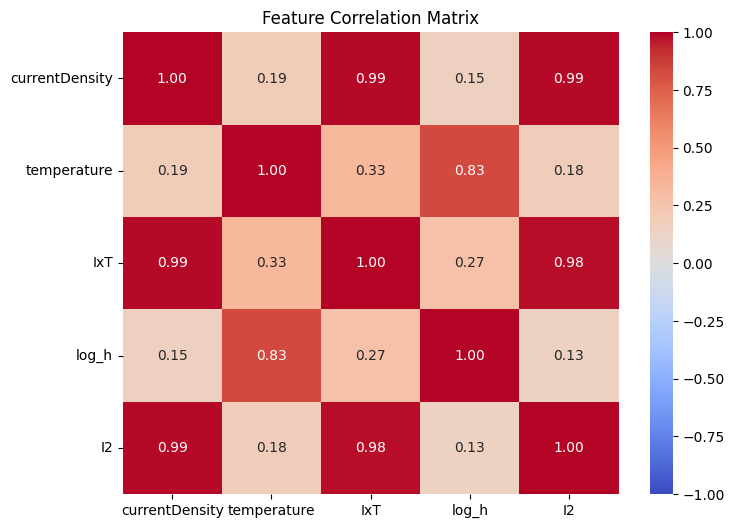


==================== 5. Pairwise Relationships (4D Scan) ====================


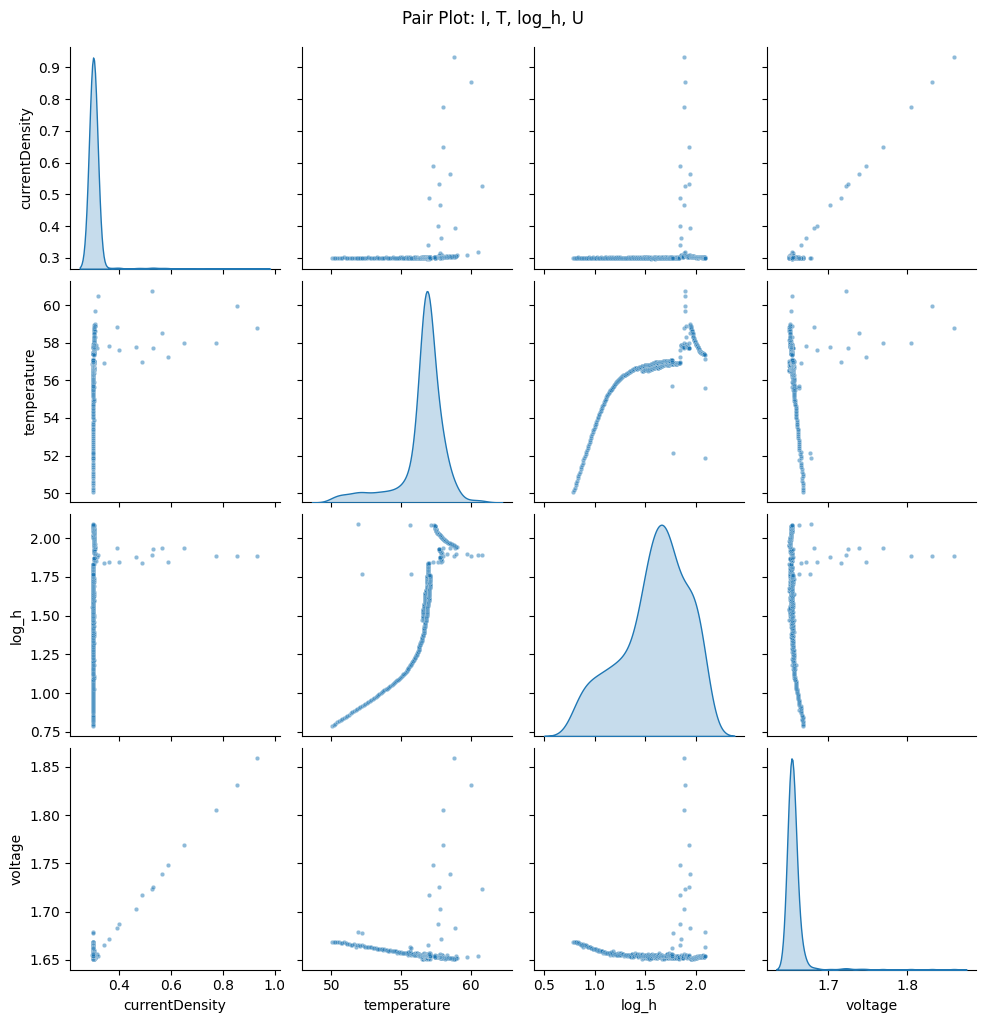


==================== 4. Interactive 3D Spatial Distribution ====================



==================== 6. Joint Distribution (Current vs Temp) ====================


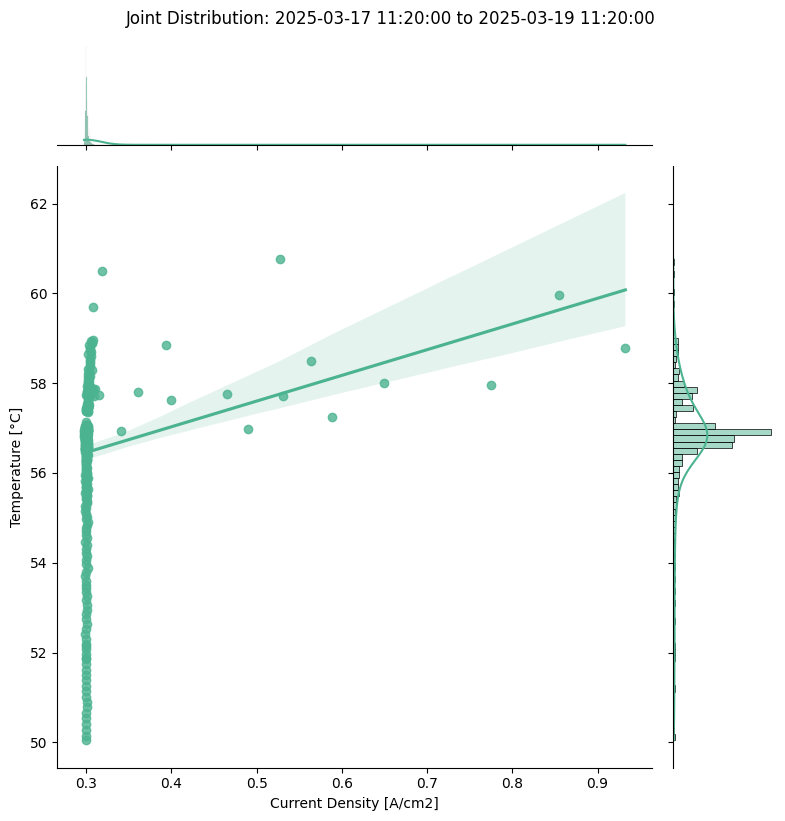


==================== 6. Joint Distribution (logh vs Temp) ====================


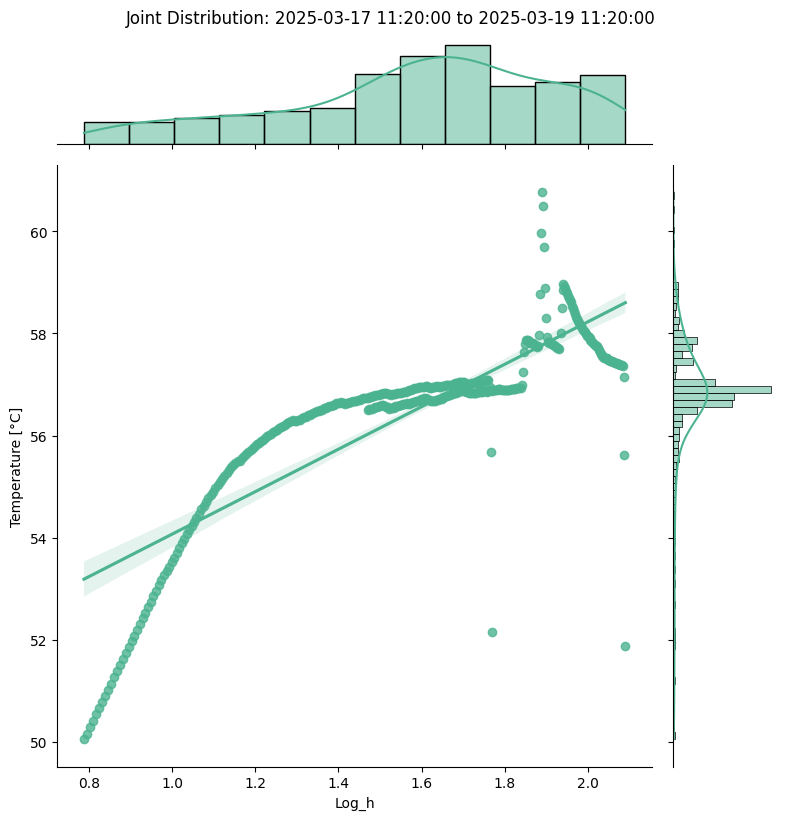

In [10]:
target_date = "2025-03-17"
print(f"Starting investigation for: {target_date}...")
investigator.run_full_diagnosis(target_date)